In [1]:
import numpy as np, pandas as pd, yfinance as yf
from scipy.optimize import minimize
import statsmodels.api as sm
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


TRADING_DAYS = 247
RF = 0.06
LOOKBACK = 100
REBAL_GAP = 63
COST_RATE = 0.0025
SLIPPAGE_BPS = 0
START_DATE = "2020-01-01"
BENCH = "^NSEI"
CAPITAL = 1_00_00_000
TOP_SECTORS = 3

sector_indices = {
    "NIFTY IT": "^CNXIT",
    "NIFTY PHARMA": "^CNXPHARMA",
    "NIFTY AUTO": "^CNXAUTO",
    "NIFTY ENERGY": "^CNXENERGY",
    "NIFTY BANK": "^NSEBANK"
}

sector_stocks = {
    "NIFTY IT":  ["TCS.NS", "INFY.NS", "HCLTECH.NS", "WIPRO.NS", "TECHM.NS"],
    "NIFTY PHARMA": ["SUNPHARMA.NS", "DRREDDY.NS", "CIPLA.NS", "APOLLOHOSP.NS", "MAXHEALTH.NS"],
    "NIFTY AUTO": ["MARUTI.NS", "TATAMOTORS.NS", "M&M.NS", "EICHERMOT.NS", "BAJAJ-AUTO.NS"],
    "NIFTY ENERGY": ["RELIANCE.NS", "ONGC.NS", "COALINDIA.NS", "NTPC.NS", "POWERGRID.NS"],
    "NIFTY BANK": ["HDFCBANK.NS", "ICICIBANK.NS", "KOTAKBANK.NS", "SBIN.NS", "AXISBANK.NS"]
}

all_tickers = list(sector_indices.values()) + [BENCH]
for s in sector_stocks.values():
    all_tickers += s

print("Downloading:", len(all_tickers), "tickers ...")
data = yf.download(sorted(set(all_tickers)), start=START_DATE, auto_adjust=True, progress=False)["Close"]
rets = data.pct_change(fill_method=None).dropna()
if BENCH not in rets.columns:
    raise ValueError(f"Benchmark {BENCH} not found in returns. Check ticker availability.")

bench = rets[BENCH]
print("Data loaded:", rets.shape)

Downloading: 31 tickers ...
Data loaded: (1242, 31)



 Sector vs. Basket Diagnostics:
      Sector  Correlation  Beta  P-value  R-squared  Tracking Error (annual)
    NIFTY IT        0.975 0.968      0.0      0.951                    0.047
NIFTY PHARMA        0.799 0.845      0.0      0.639                    0.108
  NIFTY AUTO        0.954 1.023      0.0      0.910                    0.062
NIFTY ENERGY        0.898 0.920      0.0      0.806                    0.092
  NIFTY BANK        0.978 0.992      0.0      0.957                    0.040

 Sector Annualized Covariance Matrix:
              NIFTY IT  NIFTY PHARMA  NIFTY AUTO  NIFTY ENERGY  NIFTY BANK
NIFTY IT       0.04435       0.01418     0.01612       0.01426     0.01351
NIFTY PHARMA   0.01418       0.02754     0.01553       0.01415     0.01055
NIFTY AUTO     0.01612       0.01553     0.03771       0.02379     0.02230
NIFTY ENERGY   0.01426       0.01415     0.02379       0.04013     0.02174
NIFTY BANK     0.01351       0.01055     0.02230       0.02174     0.03563


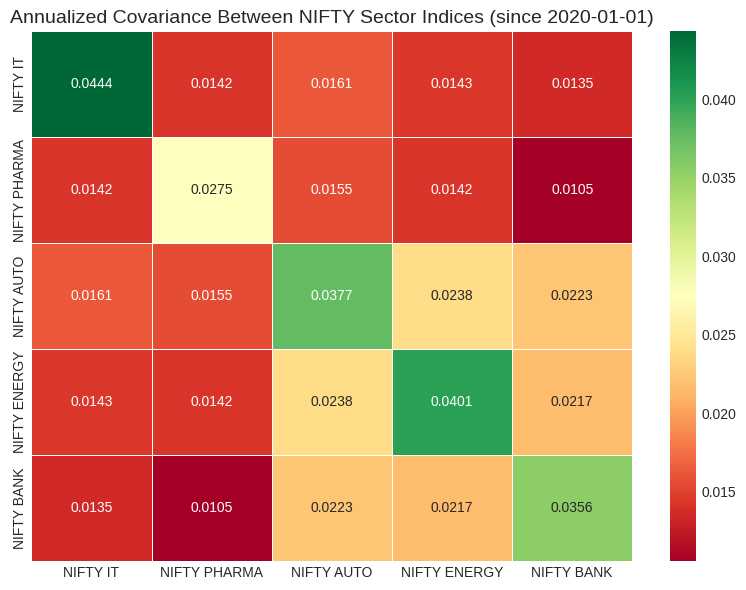

In [2]:
plt.style.use("seaborn-v0_8-whitegrid")

results = []
for sec, stocks in sector_stocks.items():
    stocks = [s for s in stocks if s in rets.columns]
    if len(stocks) == 0:
        continue
    idx = sector_indices[sec]
    if idx not in rets.columns:
        continue
    port_ret = rets[stocks].mean(axis=1)
    idx_ret = rets[idx]
    corr = port_ret.corr(idx_ret)
    X = sm.add_constant(idx_ret)
    model = sm.OLS(port_ret, X).fit()
    beta = model.params.get(idx_ret.name, np.nan)
    p_value = model.pvalues.get(idx_ret.name, np.nan)
    r_squared = model.rsquared
    diff = port_ret - idx_ret
    tracking_error = np.std(diff) * np.sqrt(TRADING_DAYS)

    results.append([sec, corr, beta, p_value, r_squared, tracking_error])

diag_df = pd.DataFrame(results, columns=["Sector", "Correlation", "Beta", "P-value", "R-squared", "Tracking Error (annual)"])
print("\n Sector vs. Basket Diagnostics:")
print(diag_df.round(3).to_string(index=False))

# Sector covariance matrix
sector_only_cols = [v for v in sector_indices.values() if v in rets.columns]
sector_only = rets[sector_only_cols].copy()
sector_only.columns = [k for k, v in sector_indices.items() if v in rets.columns]
cov_matrix = sector_only.cov() * TRADING_DAYS # annualize covariance

print("\n Sector Annualized Covariance Matrix:")
print(cov_matrix.round(5).to_string())

plt.figure(figsize=(8,6))
sns.heatmap(
    cov_matrix,
    annot=True,
    cmap="RdYlGn",
    linewidths=0.5,
    fmt=".4f" # Use .4f for better precision with covariance values
)
plt.title("Annualized Covariance Between NIFTY Sector Indices (since " + START_DATE + ")", fontsize=14)
plt.tight_layout()
plt.show()

In [3]:
def calculate_performance_metrics(returns: pd.Series, risk_free_rate_annual: float = 0.0, trading_days: int = 247) -> pd.Series:
    """
    returns: daily simple returns as a pandas Series
    risk_free_rate_annual: annual RF (e.g., 0.06 for 6%)
    """
    # Annualized (arithmetic) return & vol
    annualized_return = returns.mean() * trading_days
    annualized_volatility = returns.std() * np.sqrt(trading_days)

    # Sharpe (uses annual RF directly against annualized return)
    sharpe_ratio = (annualized_return - risk_free_rate_annual) / annualized_volatility if annualized_volatility > 0 else 0.0

    # Downside deviation
    negative_returns = returns[returns < 0]
    downside_deviation = negative_returns.std() * np.sqrt(trading_days) if len(negative_returns) else 0.0

    # Sortino (using 0% MAR).
    sortino_ratio = (annualized_return - risk_free_rate_annual) / downside_deviation if downside_deviation > 0 else 0.0

    # Max drawdown & Calmar
    cumulative_returns = (1 + returns).cumprod()
    peak = cumulative_returns.cummax()
    drawdown = (cumulative_returns / peak) - 1
    max_drawdown = drawdown.min()
    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown < 0 else 0.0

    # Geometric CAGR
    cagr_geom = cumulative_returns.iloc[-1]**(trading_days/len(returns)) - 1

    return pd.Series({
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Sortino Ratio": sortino_ratio,
        "Max Drawdown": max_drawdown,
        "Calmar Ratio": calmar_ratio,
        "CAGR (Geometric)": cagr_geom
    })


def period_return(series):
    """Compound simple daily returns in a period to a single simple return."""
    return (1 + series).prod() - 1

def hhi(weights: pd.Series):
    """Herfindahl-Hirschman Index for concentration (0..1)."""
    w = weights[weights > 0]
    return float((w**2).sum())

def summarize_gross_net(port_gross: pd.Series,
                        port_net: pd.Series,
                        bench_aligned: pd.Series,
                        risk_free_rate_annual: float = RF,
                        trading_days: int = TRADING_DAYS) -> pd.DataFrame:
    pg = calculate_performance_metrics(port_gross, risk_free_rate_annual, trading_days)
    pn = calculate_performance_metrics(port_net,   risk_free_rate_annual, trading_days)
    nb = calculate_performance_metrics(bench_aligned, risk_free_rate_annual, trading_days)

    out = pd.DataFrame({
        "Portfolio (Gross)": pg,
        "Portfolio (Net)":   pn,
        "NIFTY50":           nb
    })

    out.loc["Cost Drag (Annualized Return)"] = [
        pg["Annualized Return"] - pn["Annualized Return"],
        0.0, 0.0
    ]
    out.loc["Cost Drag (CAGR)"] = [
        pg["CAGR (Geometric)"] - pn["CAGR (Geometric)"],
        0.0, 0.0
    ]

    preferred_order = [
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Sortino Ratio",
        "Max Drawdown",
        "Calmar Ratio",
        "CAGR (Geometric)",
        "Cost Drag (Annualized Return)",
        "Cost Drag (CAGR)"
    ]

    out = out.reindex([r for r in preferred_order if r in out.index])

    return out


def ann_cov(r):
    return r.cov() * TRADING_DAYS

def hybrid_mu(window):
    """Hybrid expected return: mix of mean, recent momentum, Sharpe proxy; floor at 0."""
    mean_r = window.mean() * TRADING_DAYS
    momentum = (window.iloc[-21:].sum()) * 12
    sharpe_proxy = mean_r / window.std()
    mu = 0.6 * mean_r + 0.3 * momentum + 0.1 * sharpe_proxy
    mu = mu / (1 + window.std())
    mu = np.maximum(mu, 0)
    return mu

In [4]:
def mean_variance_optimization(mu, S, prev_w=None, penalty=0.02):
    """Maximize Sharpe (mu' w / sqrt(w' S w)) with  L1 turnover penalty vs prev_w."""
    mu = np.asarray(mu); S = np.asarray(S)
    def objective(w):
        ret = np.dot(mu, w)
        vol = np.sqrt(np.dot(w.T, np.dot(S, w)))
        reg = penalty * np.sum(np.abs(w - (prev_w if prev_w is not None else 0)))
        # minimize negative Sharpe + penalty
        return -(ret / vol if vol>0 else 0) + reg
    n = len(mu)
    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bnds = [(0, 0.4)] * n     # cap 40% to prevent overconcentration
    w0 = np.ones(n)/n
    res = minimize(objective, w0, method='SLSQP', bounds=bnds, constraints=cons)
    return res.x if res.success else w0/w0.sum()

def risk_parity_optimization(S):
    """Minimize squared deviation of risk contributions."""
    S = np.asarray(S)
    def objective(w):
        port_var = np.dot(w.T, np.dot(S, w))
        if port_var <= 0:
            return 0
        mrc = np.dot(S, w)                        # marginal risk contributions
        rc = w * mrc / np.sqrt(port_var)          # risk contributions
        return np.sum((rc - rc.mean())**2)
    n = S.shape[0]
    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bnds = [(0, 1)] * n
    w0 = np.ones(n) / n
    res = minimize(objective, w0, method="SLSQP", bounds=bnds, constraints=cons)
    return res.x if res.success else w0 / w0.sum()

In [5]:
def run_dynamic_two_level_mvo(rets, bench):
    port_parts_gross, port_parts_net, ledger = [], [], []
    prev_w = pd.Series(0.0, index=rets.columns)
    sector_w_prev = None
    last_weights = None

    for i in range(LOOKBACK, len(rets.index)-REBAL_GAP, REBAL_GAP):
        win = rets.iloc[i-LOOKBACK:i]
        hold = rets.iloc[i:i+REBAL_GAP]
        period_start, period_end = hold.index[0], hold.index[-1]

        # --- Sector level (select TOP_SECTORS via hybrid scores) ---
        sec_data = win[[v for v in sector_indices.values() if v in win.columns]]
        if sec_data.shape[1] == 0:
            continue
        mu_s = hybrid_mu(sec_data)
        cov_s = ann_cov(sec_data)
        # score = mu / sigma
        sec_scores = mu_s / np.sqrt(np.diag(cov_s))
        top_secs = sec_scores.nlargest(min(TOP_SECTORS, len(sec_scores))).index
        mu_s, cov_s = mu_s[top_secs], cov_s.loc[top_secs, top_secs]

        prev_w_sector = None if sector_w_prev is None else sector_w_prev.reindex(mu_s.index).fillna(0)
        w_sector = pd.Series(
            mean_variance_optimization(mu_s.values, cov_s.values, prev_w=prev_w_sector),
            index=mu_s.index
        )
        w_sector = w_sector[w_sector > 1e-6]

        # --- Stock level (within each chosen sector) ---
        final_w = {}
        for sec_name, sec_symbol in sector_indices.items():
            if sec_symbol not in w_sector.index:
                continue
            sector_weight = w_sector[sec_symbol]
            stocks = [s for s in sector_stocks.get(sec_name, []) if s in win.columns]
            if len(stocks) == 0:
                continue
            mu_i = hybrid_mu(win[stocks])
            cov_i = ann_cov(win[stocks])
            w_intra = pd.Series(mean_variance_optimization(mu_i.values, cov_i.values), index=mu_i.index)
            for s in w_intra.index:
                final_w[s] = w_intra[s] * sector_weight

        w = pd.Series(final_w).fillna(0)

        # --- turnover & cost ---
        turnover = np.abs(w - prev_w.reindex(w.index).fillna(0)).sum()
        cost_as_return = turnover * (COST_RATE + SLIPPAGE_BPS/1e4)

        # --- period returns: gross & net ---
        gross_series = hold[w.index].mul(w, axis=1).sum(axis=1)
        net_series = gross_series.copy()
        if len(net_series) > 0:
            net_series.iloc[0] -= cost_as_return

        # --- store & update state ---
        port_parts_gross.append(gross_series)
        port_parts_net.append(net_series)
        prev_w = pd.Series(0.0, index=rets.columns)
        prev_w.loc[w.index] = w.values
        sector_w_prev = w_sector.copy()
        last_weights = w.copy()

        # --- log ledger row ---
        ledger.append({
            "Rebalance_Start": period_start,
            "Rebalance_End": period_end,
            "Turnover": float(turnover),
            "Cost_as_Return": float(cost_as_return),
            "Gross_Period_Return": float(period_return(gross_series)),
            "Net_Period_Return": float(period_return(net_series)),
            "Positions": int((w>0).sum()),
            "HHI": hhi(w)
        })

    if len(port_parts_net) == 0:
        raise RuntimeError("No MVO periods produced. Check data/lookback settings.")
    port_gross = pd.concat(port_parts_gross).sort_index()
    port_net = pd.concat(port_parts_net).sort_index()
    bench_aligned = bench.loc[port_net.index]

    ledger_df = pd.DataFrame(ledger)
    ledger_df["Cost_bps"] = (ledger_df["Cost_as_Return"] * 1e4).round(1)
    ledger_df["Turnover_%"] = (ledger_df["Turnover"]*100).round(2)

    return port_gross, port_net, bench_aligned, ledger_df,last_weights


=== MVO — Rebalance Ledger ===
Rebalance_Start Rebalance_End  Turnover_%  Cost_bps  Gross_Period_Return  Net_Period_Return  Positions      HHI
     2021-01-20    2021-05-04      100.00      25.0             0.014149           0.011641         13 0.120655
     2021-05-07    2021-08-20       94.15      23.5             0.198287           0.195465         15 0.119117
     2021-08-23    2021-11-23       74.14      18.5             0.092676           0.090652         14 0.117572
     2021-11-24    2022-02-21       71.23      17.8             0.000422          -0.001372         15 0.126551
     2022-02-22    2022-05-26       61.93      15.5            -0.017420          -0.018949         14 0.125729
     2022-05-27    2022-08-25      117.39      29.3             0.133107           0.129780         13 0.124254
     2022-08-26    2022-11-28       61.60      15.4             0.038503           0.036910         12 0.126670
     2022-11-29    2023-02-28       81.43      20.4            -0.078137

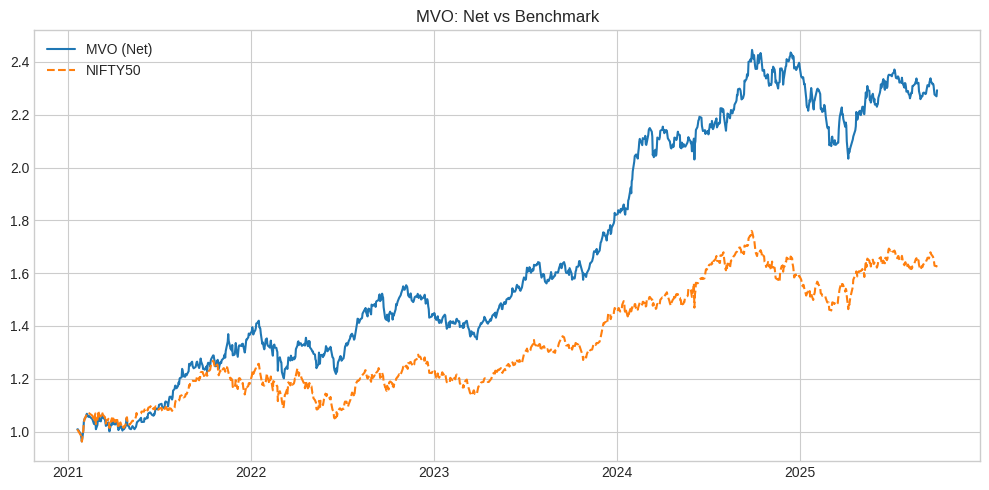


 FORWARD ALLOCATION (as of last rebalance) ===
        Stock  Weight (%)  Price (₹)  Shares  Value (₹)
  RELIANCE.NS       16.00    1379.40    1159 1598724.63
      NTPC.NS       16.00     340.60    4697 1599798.23
 ICICIBANK.NS       11.31    1388.90     814 1130564.62
 KOTAKBANK.NS        8.78    2158.80     406  876472.82
APOLLOHOSP.NS        8.00    7765.00     103  799795.00
     CIPLA.NS        6.94    1561.90     444  693483.61
 COALINDIA.NS        6.22     382.40    1626  621782.39
  AXISBANK.NS        3.92    1169.10     334  390479.39
   DRREDDY.NS        3.57    1239.70     287  355793.89
 POWERGRID.NS        1.78     289.85     613  177678.05
 MAXHEALTH.NS        1.49    1162.90     128  148851.20

Invested: ₹8,393,424 | Leftover cash: ₹1,606,576 | Capital: ₹10,000,000

Sector Weights (from stock weights):
NIFTY ENERGY    40.0%
NIFTY BANK      24.0%
NIFTY PHARMA    20.0%
dtype: object


In [6]:
port_gross_mvo, port_net_mvo, bench_mvo, ledger_mvo, mvo_last_weights = run_dynamic_two_level_mvo(rets, bench)


print("\n=== MVO — Rebalance Ledger ===")
cols = ["Rebalance_Start","Rebalance_End","Turnover_%","Cost_bps","Gross_Period_Return","Net_Period_Return","Positions","HHI"]
print(ledger_mvo[cols].to_string(index=False))

total_cost_mvo = ledger_mvo["Cost_as_Return"].sum()
print(f"\nMVO Total Cost Drag (sum of one-off period drags): {total_cost_mvo:.2%}")

mvo_summary = summarize_gross_net(port_gross_mvo, port_net_mvo, bench_mvo)
print("\n=== MVO  Net vs NIFTY50 ===")
print(mvo_summary.applymap(lambda x: f"{x:.3f}" if isinstance(x, (int,float)) else x))

# Plot gross vs net
cum_gross = (1+port_gross_mvo).cumprod()
cum_net   = (1+port_net_mvo).cumprod()
cum_bench = (1+bench_mvo).cumprod()
plt.figure(figsize=(10,5))
plt.plot(cum_net,   label="MVO (Net)")
plt.plot(cum_bench, label="NIFTY50", ls="--")
plt.legend(); plt.grid(True); plt.title("MVO: Net vs Benchmark"); plt.tight_layout(); plt.show()


print("\n FORWARD ALLOCATION (as of last rebalance) ===")
lw = mvo_last_weights[mvo_last_weights > 1e-4].sort_values(ascending=False)


latest_prices = data.reindex(columns=lw.index).iloc[-1]
valid = latest_prices.dropna().index
lw = lw.reindex(valid).fillna(0)
latest_prices = latest_prices.loc[valid]

alloc_value_target = lw * CAPITAL
shares = np.floor(alloc_value_target / latest_prices).astype(int)

invested = (shares * latest_prices).sum()
leftover_cash = CAPITAL - invested

forward_alloc_mvo = pd.DataFrame({
    "Stock": lw.index,
    "Weight (%)": (lw*100).round(2),
    "Price (₹)": latest_prices.round(2),
    "Shares": shares,
    "Value (₹)": (shares * latest_prices).round(2)
}).sort_values("Weight (%)", ascending=False)

print(forward_alloc_mvo.to_string(index=False))
print(f"\nInvested: ₹{invested:,.0f} | Leftover cash: ₹{leftover_cash:,.0f} | Capital: ₹{CAPITAL:,.0f}")

stock_to_sector = {stk: sec for sec, lst in sector_stocks.items() for stk in lst}
sector_rollup = lw.groupby(lw.index.map(lambda x: stock_to_sector.get(x, "Other"))).sum().sort_values(ascending=False)
print("\nSector Weights (from stock weights):")
print((sector_rollup*100).round(2).astype(str) + "%")

In [7]:
def run_dynamic_two_level_rp(rets, bench):
    port_parts_gross, port_parts_net, ledger = [], [], []
    prev_w = pd.Series(0.0, index=rets.columns)
    last_weights = None

    for i in range(LOOKBACK, len(rets.index)-REBAL_GAP, REBAL_GAP):
        win = rets.iloc[i-LOOKBACK:i]
        hold = rets.iloc[i:i+REBAL_GAP]
        period_start, period_end = hold.index[0], hold.index[-1]

        # --- Sector level RP ---
        sec_cols = [v for v in sector_indices.values() if v in win.columns]
        if len(sec_cols) == 0:
            continue
        cov_s = ann_cov(win[sec_cols])
        w_sector = pd.Series(risk_parity_optimization(cov_s.values), index=sec_cols)

        # --- Stock level RP ---
        final_w = {}
        for sec_name, sec_symbol in sector_indices.items():
            if sec_symbol not in w_sector.index:
                continue
            sector_weight = w_sector[sec_symbol]
            stocks = [s for s in sector_stocks.get(sec_name, []) if s in win.columns]
            if len(stocks)==0:
                continue
            cov_i = ann_cov(win[stocks])
            w_intra = pd.Series(risk_parity_optimization(cov_i.values), index=stocks)
            for s in w_intra.index:
                final_w[s] = w_intra[s] * sector_weight

        w = pd.Series(final_w).fillna(0)

        # turnover & cost
        turnover = np.abs(w - prev_w.reindex(w.index).fillna(0)).sum()
        cost_as_return = turnover * (COST_RATE + SLIPPAGE_BPS/1e4)

        # returns: gross & net
        gross_series = hold[w.index].mul(w, axis=1).sum(axis=1)
        net_series = gross_series.copy()
        if len(net_series) > 0:
            net_series.iloc[0] -= cost_as_return

        port_parts_gross.append(gross_series)
        port_parts_net.append(net_series)
        prev_w = pd.Series(0.0, index=rets.columns)
        prev_w.loc[w.index] = w.values
        last_weights = w.copy()

        ledger.append({
            "Rebalance_Start": period_start,
            "Rebalance_End": period_end,
            "Turnover": float(turnover),
            "Cost_as_Return": float(cost_as_return),
            "Gross_Period_Return": float(period_return(gross_series)),
            "Net_Period_Return": float(period_return(net_series)),
            "Positions": int((w>0).sum()),
            "HHI": hhi(w)
        })

    if len(port_parts_net) == 0:
        raise RuntimeError("No RP periods produced. Check data/lookback settings.")
    port_gross = pd.concat(port_parts_gross).sort_index()
    port_net = pd.concat(port_parts_net).sort_index()
    bench_aligned = bench.loc[port_net.index]
    ledger_df = pd.DataFrame(ledger)
    ledger_df["Cost_bps"] = (ledger_df["Cost_as_Return"] * 1e4).round(1)
    ledger_df["Turnover_%"] = (ledger_df["Turnover"]*100).round(2)
    return port_gross, port_net, bench_aligned, ledger_df, last_weights


=== Risk Parity — Rebalance Ledger ===
Rebalance_Start Rebalance_End  Turnover_%  Cost_bps  Gross_Period_Return  Net_Period_Return  Positions      HHI
     2021-01-20    2021-05-04      100.00      25.0             0.023936           0.021399         25 0.042045
     2021-05-07    2021-08-20       14.64       3.7             0.114084           0.113677         25 0.042116
     2021-08-23    2021-11-23        8.78       2.2             0.095478           0.095238         25 0.042224
     2021-11-24    2022-02-21       17.46       4.4             0.018523           0.018077         25 0.042304
     2022-02-22    2022-05-26       15.28       3.8            -0.020016          -0.020391         25 0.042554
     2022-05-27    2022-08-25       10.22       2.6             0.069920           0.069649         25 0.041762
     2022-08-26    2022-11-28       11.46       2.9             0.068230           0.067925         25 0.041649
     2022-11-29    2023-02-28       12.47       3.1            -

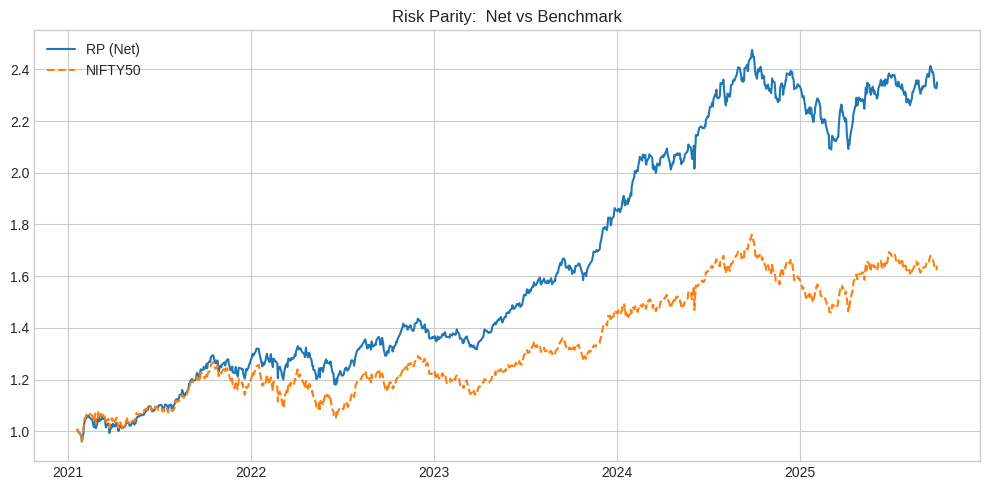


 FORWARD ALLOCATION (as of last rebalance) ===
        Stock  Weight (%)  Price (₹)  Shares  Value (₹)
 ICICIBANK.NS        5.33    1388.90     383  531948.71
      SBIN.NS        5.13     879.35     582  511781.69
APOLLOHOSP.NS        5.04    7765.00      64  496960.00
   DRREDDY.NS        5.00    1239.70     402  498359.38
    MARUTI.NS        4.99   16320.00      30  489600.00
 SUNPHARMA.NS        4.84    1664.80     290  482792.01
 KOTAKBANK.NS        4.83    2158.80     223  481412.41
     CIPLA.NS        4.67    1561.90     298  465446.21
       TCS.NS        4.43    2979.00     148  440892.00
  AXISBANK.NS        4.23    1169.10     362  423214.19
  RELIANCE.NS        3.88    1379.40     281  387611.41
 COALINDIA.NS        3.78     382.40     987  377428.79
 EICHERMOT.NS        3.54    6908.50      51  352333.50
     WIPRO.NS        3.51     251.97    1391  350490.27
 POWERGRID.NS        3.38     289.85    1165  337675.26
      NTPC.NS        3.30     340.60     967  329360.21


In [8]:
port_gross_rp, port_net_rp, bench_rp, ledger_rp, last_weights = run_dynamic_two_level_rp(rets, bench)

print("\n=== Risk Parity — Rebalance Ledger ===")
print(ledger_rp[cols].to_string(index=False))
total_cost_rp = ledger_rp["Cost_as_Return"].sum()
print(f"\nRisk Parity Total Cost Drag: {total_cost_rp:.2%}")

rp_summary = summarize_gross_net(port_gross_rp, port_net_rp, bench_rp)
print("\n=== Risk Parity — Gross vs Net vs NIFTY50 ===")
print(rp_summary.applymap(lambda x: f"{x:.3f}" if isinstance(x, (int,float)) else x))

# Plot gross vs net
cum_net   = (1+port_net_rp).cumprod()
cum_bench = (1+bench_rp).cumprod()
plt.figure(figsize=(10,5))
plt.plot(cum_net,   label="RP (Net)")
plt.plot(cum_bench, label="NIFTY50", ls="--")
plt.legend(); plt.grid(True); plt.title("Risk Parity:  Net vs Benchmark"); plt.tight_layout(); plt.show()


print("\n FORWARD ALLOCATION (as of last rebalance) ===")
lw = last_weights[last_weights > 1e-4].sort_values(ascending=False)

# guard against missing prices
latest_prices = data.reindex(columns=lw.index).iloc[-1]
valid = latest_prices.dropna().index
lw = lw.reindex(valid).fillna(0)
latest_prices = latest_prices.loc[valid]

alloc_value_target = (lw * CAPITAL)
shares = np.floor(alloc_value_target / latest_prices).astype(int)
invested = (shares * latest_prices).sum()
leftover_cash = CAPITAL - invested

future_allocation = pd.DataFrame({
    "Stock": lw.index,
    "Weight (%)": (lw*100).round(2),
    "Price (₹)": latest_prices.round(2),
    "Shares": shares,
    "Value (₹)": (shares * latest_prices).round(2)
}).sort_values("Weight (%)", ascending=False)

print(future_allocation.to_string(index=False))
print(f"\nInvested: ₹{invested:,.0f} | Leftover cash: ₹{leftover_cash:,.0f} | Capital: ₹{CAPITAL:,.0f}")